In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [2]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

# Check class balance for potential targets (for class_imbalance skip decision)
_class_balance = {}
for col in _binary_columns + [c for c in _potential_targets if c not in _binary_columns]:
    try:
        counts = df_raw[col].value_counts(normalize=True)
        if len(counts) >= 2:
            majority_pct = float(counts.iloc[0] * 100)
            minority_pct = float(counts.iloc[1] * 100)
            _class_balance[col] = {
                'majority_pct': round(majority_pct, 1),
                'minority_pct': round(minority_pct, 1),
                'is_imbalanced': bool(majority_pct > 70)
            }
    except:
        pass

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
    'class_balance': _class_balance,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

In [4]:

skewed_cols = ['A', 'B', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']
binary_cols = ['A', 'B', 'S', 'T']

print('--- Value Counts for Skewed Columns ---')
for col in skewed_cols:
    print(f'\nColumn: {col}')
    print(df_raw[col].value_counts(normalize=True).round(3))

print('\n--- Value Counts for Binary Columns (re-confirming) ---')
for col in binary_cols:
    print(f'\nColumn: {col}')
    print(df_raw[col].value_counts(normalize=True).round(3))


--- Value Counts for Skewed Columns ---

Column: A
A
1   0.9970
0   0.0030
Name: proportion, dtype: float64

Column: B
B
1   0.9180
0   0.0820
Name: proportion, dtype: float64

Column: I
I
26.3480    0.0020
11.1034    0.0020
21.6127    0.0020
8.4821     0.0020
15.8712    0.0020
            ...  
158.1773   0.0010
6.0718     0.0010
63.1971    0.0010
30.4619    0.0010
40.5257    0.0010
Name: proportion, Length: 1140, dtype: float64

Column: J
J
13.6668   0.0020
4.0090    0.0020
9.6693    0.0020
3.4283    0.0020
3.6940    0.0020
           ...  
84.8655   0.0010
0.9375    0.0010
27.3777   0.0010
13.9670   0.0010
12.6049   0.0010
Name: proportion, Length: 1140, dtype: float64

Column: K
K
0.0000    0.0100
2.5564    0.0020
0.3972    0.0020
0.9034    0.0020
1.4670    0.0020
           ...  
51.2537   0.0010
0.0311    0.0010
8.0677    0.0010
1.7633    0.0010
4.7409    0.0010
Name: proportion, Length: 1129, dtype: float64

Column: L
L
0.0000    0.0970
0.1925    0.0020
0.1293    0.0020
0.2748  


--- Scatter Plots for Top Correlated Pairs ---


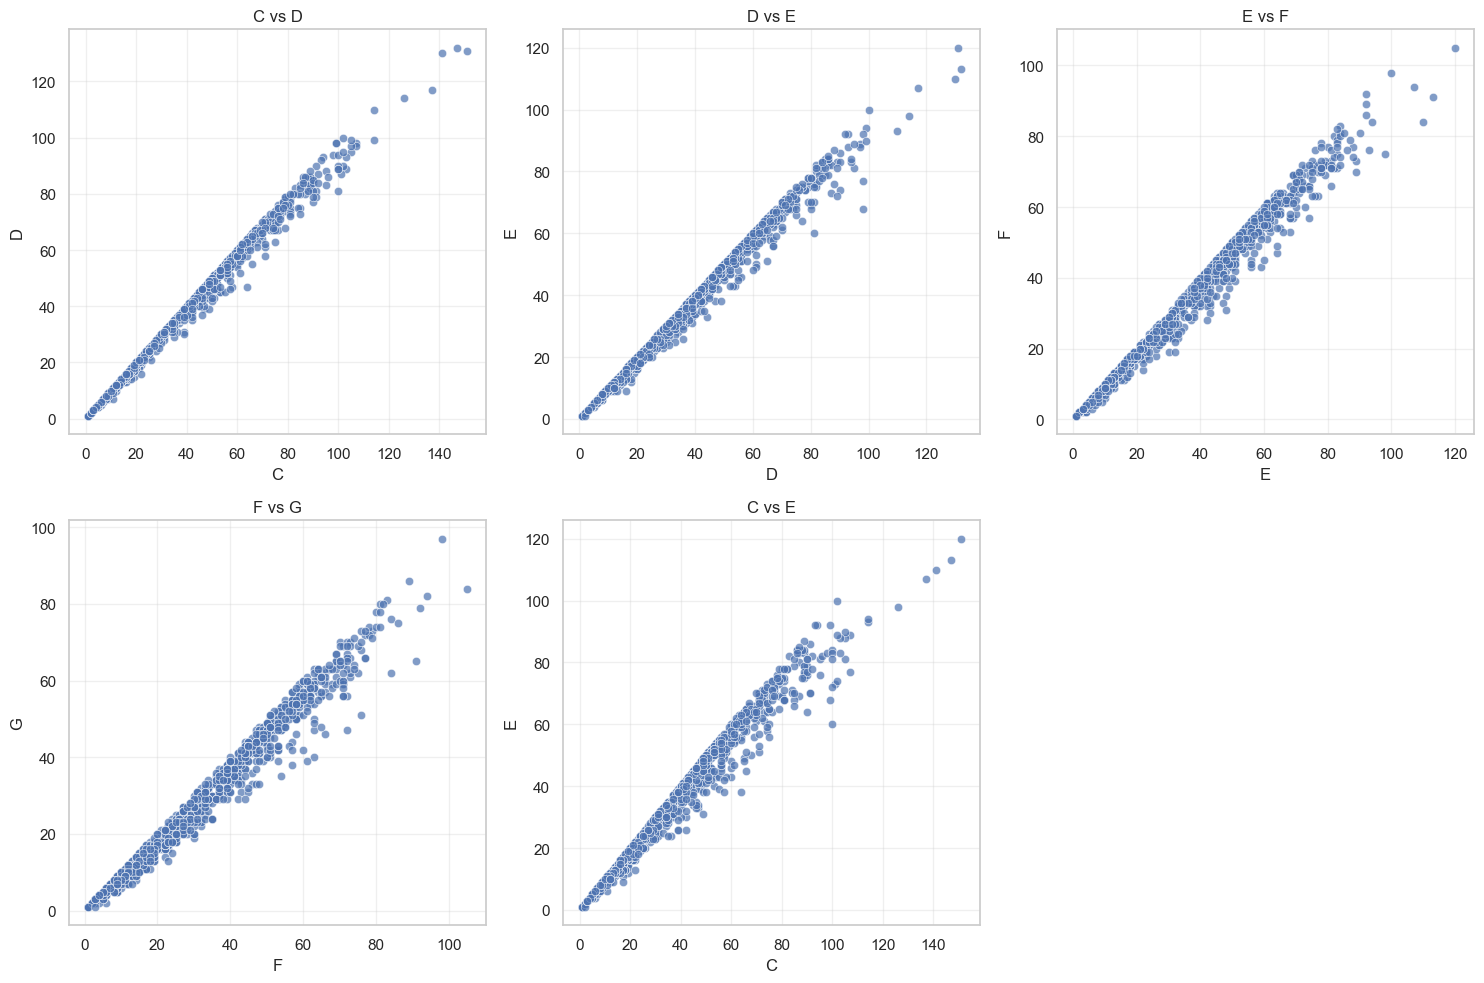

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

top_correlated_pairs = [['C', 'D'], ['D', 'E'], ['E', 'F'], ['F', 'G'], ['C', 'E']]

print('\n--- Scatter Plots for Top Correlated Pairs ---')
plt.figure(figsize=(15, 10))
for i, (col1, col2) in enumerate(top_correlated_pairs):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.scatterplot(x=df_raw[col1], y=df_raw[col2], alpha=0.7)
    plt.title(f'{col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
plt.tight_layout()
plt.show()


Chart 1: This heatmap visualizes the pairwise correlations between columns C, D, E, F, and G. It helps identify the strength and direction of linear relationships among these features.
Chart 2: These four count plots display the distribution of values for binary columns A, B, S, and T. They reveal the proportion of each category (0 or 1) within these features.
Chart 3: These three histograms illustrate the distribution of values for highly skewed numerical columns I, J, and K. The kernel density estimate (KDE) overlay helps visualize the shape of the distributions, highlighting their skewness.


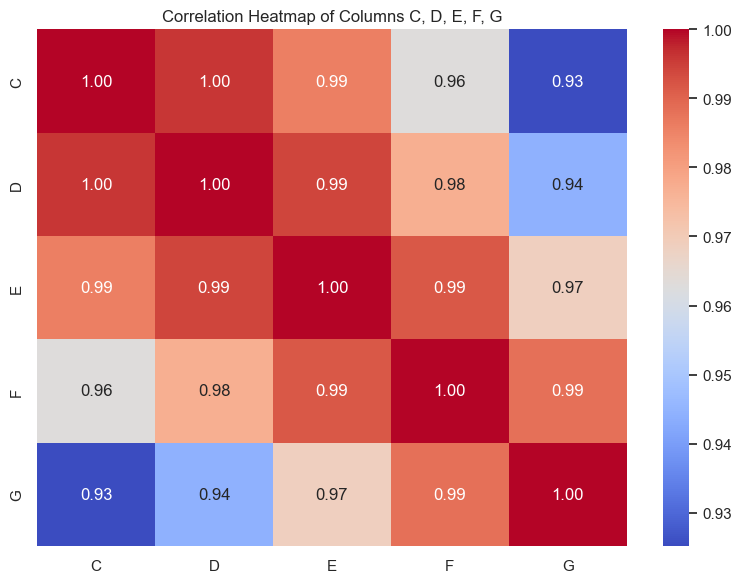

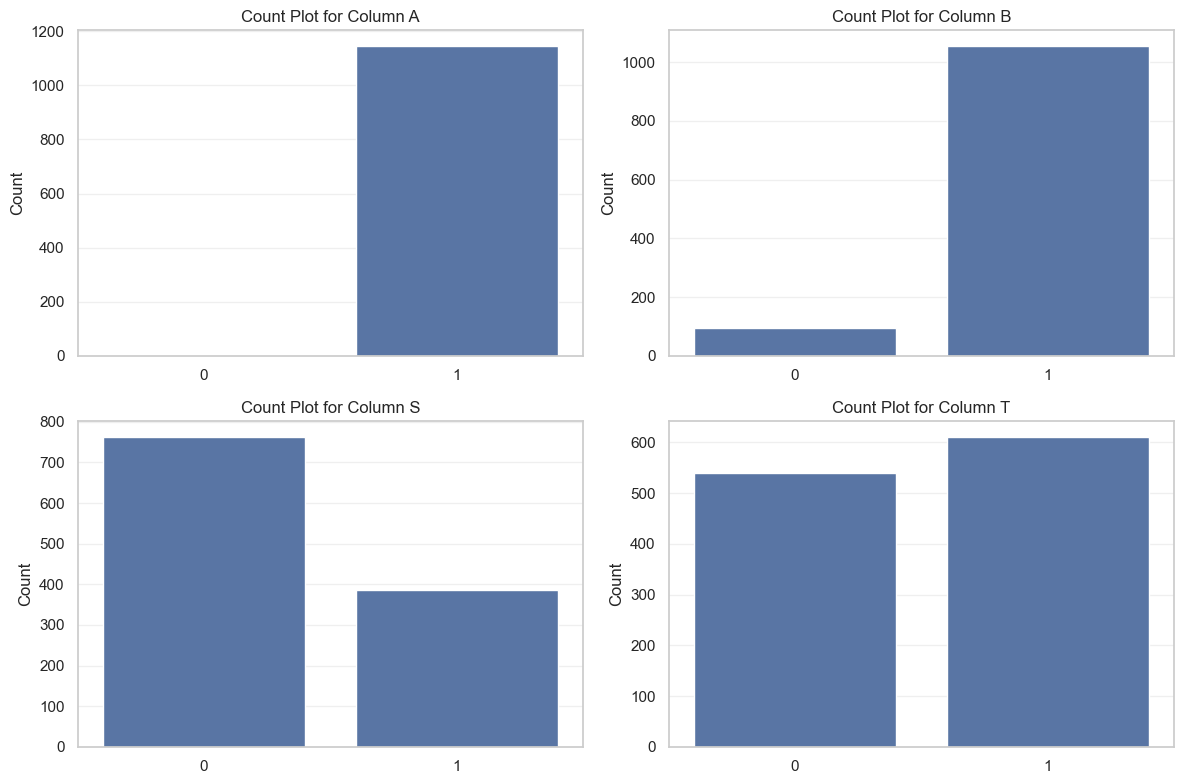

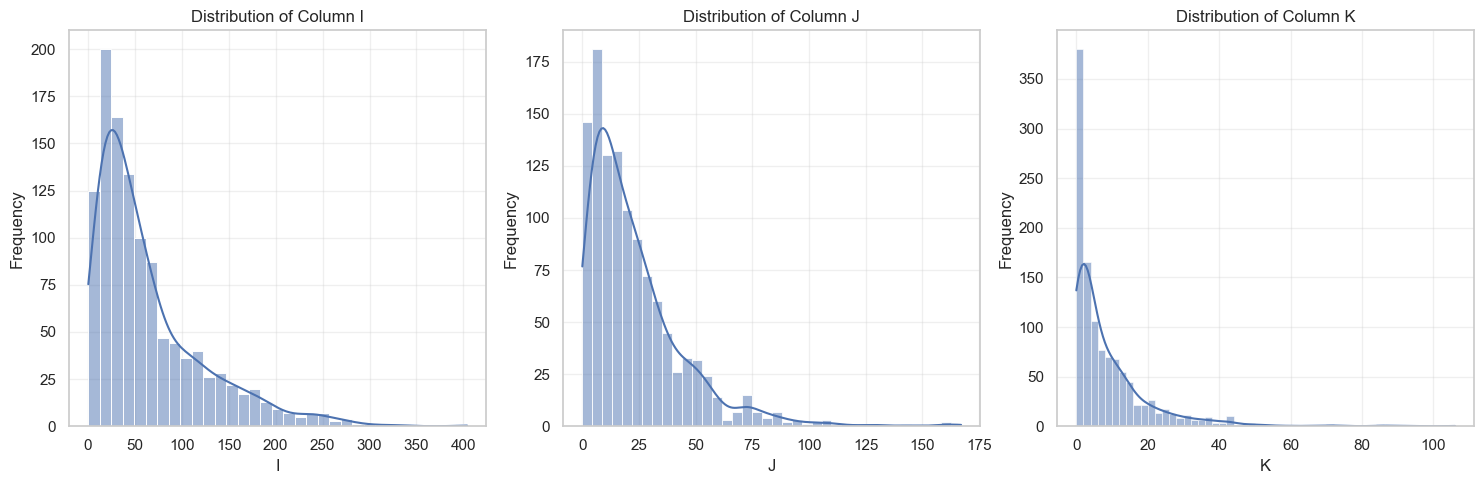

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation Heatmap for 'C', 'D', 'E', 'F', 'G'
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[['C', 'D', 'E', 'F', 'G']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Columns C, D, E, F, G')
plt.tight_layout()
plt.show()
print("Chart 1: This heatmap visualizes the pairwise correlations between columns C, D, E, F, and G. It helps identify the strength and direction of linear relationships among these features.")

# 2. Count Plots for Binary Columns 'A', 'B', 'S', 'T'
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

binary_cols = ['A', 'B', 'S', 'T']
for i, col in enumerate(binary_cols):
    sns.countplot(x=col, data=df_raw, ax=axes[i])
    axes[i].set_title(f'Count Plot for Column {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()
print("Chart 2: These four count plots display the distribution of values for binary columns A, B, S, and T. They reveal the proportion of each category (0 or 1) within these features.")

# 3. Histograms for Highly Skewed Columns 'I', 'J', 'K'
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

skewed_cols = ['I', 'J', 'K']
for i, col in enumerate(skewed_cols):
    sns.histplot(df_raw[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Column {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Chart 3: These three histograms illustrate the distribution of values for highly skewed numerical columns I, J, and K. The kernel density estimate (KDE) overlay helps visualize the shape of the distributions, highlighting their skewness.")

These histograms display the distributions of the highly skewed numerical columns L, M, N, O, and P. They illustrate the shape, spread, and central tendency of values for these features, often showing a concentration of data at one end and a long tail on the other, characteristic of skewed distributions.


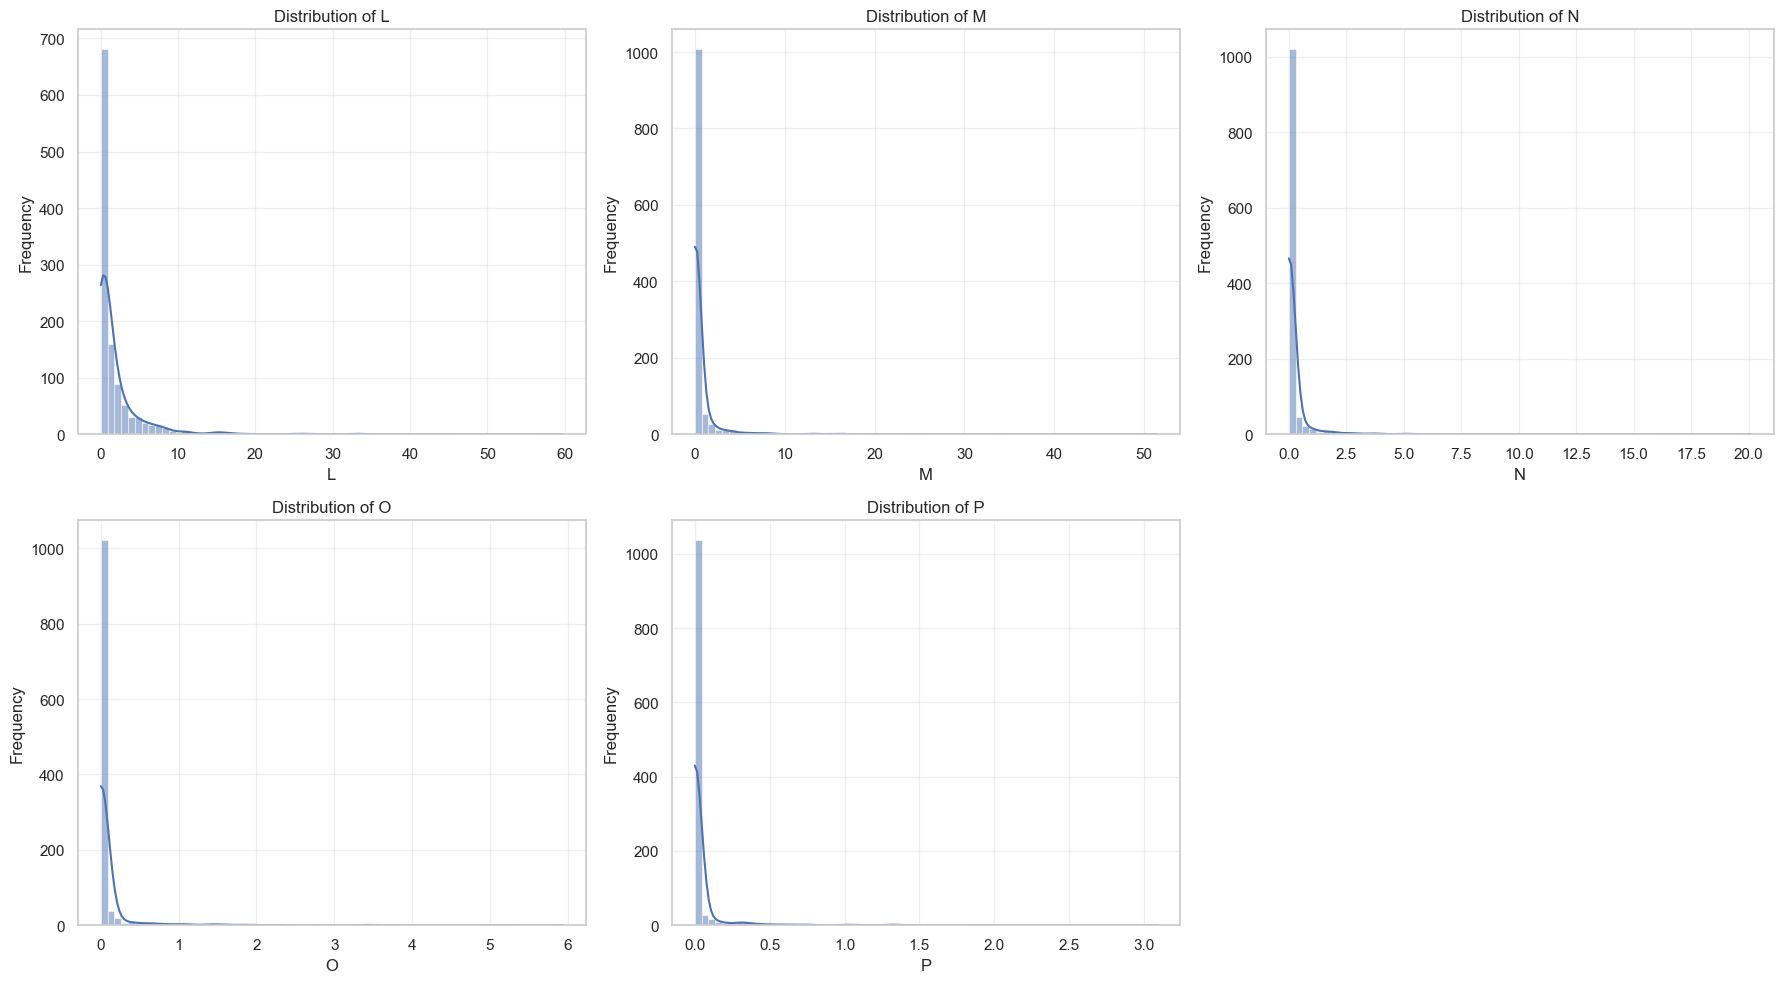

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

skewed_columns_to_plot = ['L', 'M', 'N', 'O', 'P']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for i, col in enumerate(skewed_columns_to_plot):
    sns.histplot(df_raw[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(skewed_columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("These histograms display the distributions of the highly skewed numerical columns L, M, N, O, and P. They illustrate the shape, spread, and central tendency of values for these features, often showing a concentration of data at one end and a long tail on the other, characteristic of skewed distributions.")

This heatmap visualizes the strong correlations between columns C, D, E, F, and G, showing their pairwise linear relationships and magnitudes.
These count plots illustrate the distribution of the imbalanced binary columns A and B, clearly showing the disproportionate number of observations for each category.


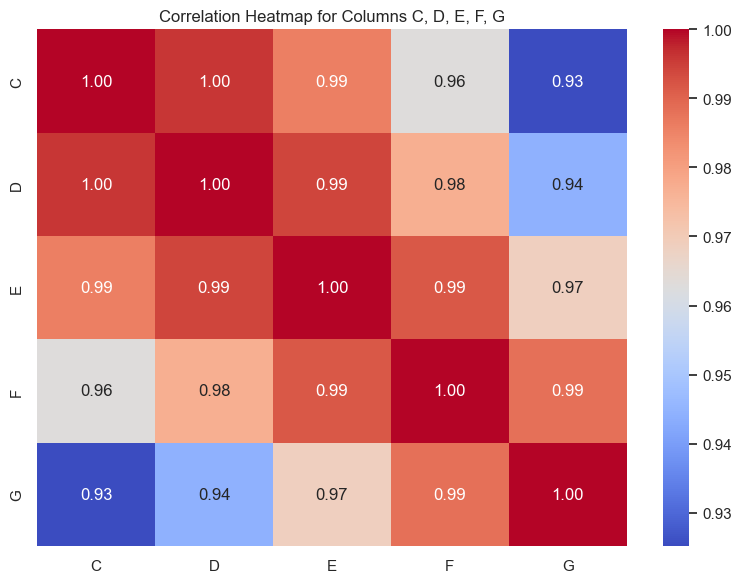

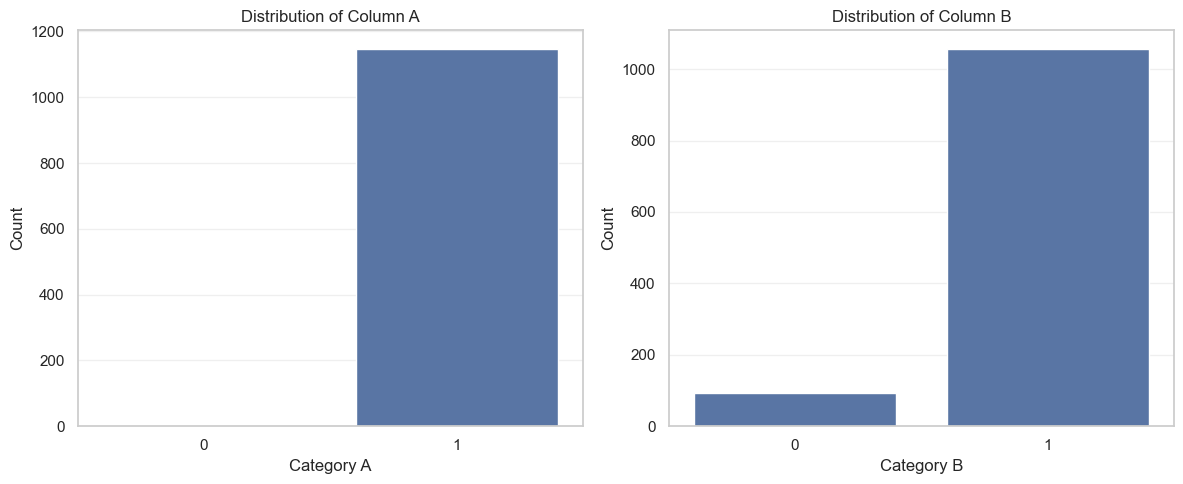

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation heatmap for columns ['C', 'D', 'E', 'F', 'G']
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[['C', 'D', 'E', 'F', 'G']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for Columns C, D, E, F, G')
plt.tight_layout()
plt.show()

print('This heatmap visualizes the strong correlations between columns C, D, E, F, and G, showing their pairwise linear relationships and magnitudes.')

# 2. Count plots for imbalanced binary columns ['A', 'B']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='A', data=df_raw, ax=axes[0])
axes[0].set_title('Distribution of Column A')
axes[0].set_xlabel('Category A')
axes[0].set_ylabel('Count')

sns.countplot(x='B', data=df_raw, ax=axes[1])
axes[1].set_title('Distribution of Column B')
axes[1].set_xlabel('Category B')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('These count plots illustrate the distribution of the imbalanced binary columns A and B, clearly showing the disproportionate number of observations for each category.')

In [17]:
import scipy.stats as stats
import pandas as pd

df = df_raw # Use the best available DataFrame

print("--- Shapiro-Wilk Normality Tests ---")
shapiro_results = {}
for col in NUMERIC_COLUMNS:
    # Shapiro-Wilk test requires data to be finite, so drop NaNs for the test
    data = df[col].dropna()
    if len(data) >= 3 and len(data) <= 5000: # Shapiro-Wilk is best for smaller samples
        stat, p = stats.shapiro(data)
        shapiro_results[col] = {'statistic': stat, 'p_value': p}
        print(f"Column {col}: Statistic={stat:.4f}, p-value={p:.4f}")
    elif len(data) > 5000:
        print(f"Column {col}: Sample size too large for Shapiro-Wilk (>5000), skipping.")
    else:
        print(f"Column {col}: Not enough data for Shapiro-Wilk (n<3).")

print("\n--- Pearson Correlation Significance (p-values) for C, D, E, F, G ---")
highly_correlated_cols = ['C', 'D', 'E', 'F', 'G']
correlation_p_values = pd.DataFrame(index=highly_correlated_cols, columns=highly_correlated_cols)

for i in range(len(highly_correlated_cols)):
    for j in range(i + 1, len(highly_correlated_cols)):
        col1 = highly_correlated_cols[i]
        col2 = highly_correlated_cols[j]
        # Pearsonr requires finite data
        clean_df = df[[col1, col2]].dropna()
        if not clean_df.empty:
            corr, p_value = stats.pearsonr(clean_df[col1], clean_df[col2])
            correlation_p_values.loc[col1, col2] = p_value
            correlation_p_values.loc[col2, col1] = p_value # Symmetric matrix
            print(f"Correlation between {col1} and {col2}: p-value={p_value:.4f}")


print("\nCorrelation p-value Matrix:")
print(correlation_p_values.fillna(1.0).round(4)) # Fill diagonal with 1.0 or NaN if preferred, but p-value of 1.0 means no correlation with itself.

--- Shapiro-Wilk Normality Tests ---
Column A: Statistic=0.0318, p-value=0.0000
Column B: Statistic=0.3041, p-value=0.0000
Column C: Statistic=0.9452, p-value=0.0000
Column D: Statistic=0.9506, p-value=0.0000
Column E: Statistic=0.9511, p-value=0.0000
Column F: Statistic=0.9476, p-value=0.0000
Column G: Statistic=0.9389, p-value=0.0000
Column H: Statistic=0.9299, p-value=0.0000
Column I: Statistic=0.8322, p-value=0.0000
Column J: Statistic=0.8154, p-value=0.0000
Column K: Statistic=0.7024, p-value=0.0000
Column L: Statistic=0.4604, p-value=0.0000
Column M: Statistic=0.2094, p-value=0.0000
Column N: Statistic=0.1887, p-value=0.0000
Column O: Statistic=0.2189, p-value=0.0000
Column P: Statistic=0.2090, p-value=0.0000
Column Q: Statistic=0.9854, p-value=0.0000
Column R: Statistic=0.9697, p-value=0.0000
Column S: Statistic=0.5965, p-value=0.0000
Column T: Statistic=0.6352, p-value=0.0000

--- Pearson Correlation Significance (p-values) for C, D, E, F, G ---
Correlation between C and D: p-v